In [28]:
library("dagitty")
library("DiagrammeR")
library("visNetwork")
library("rsvg")
library("DiagrammeRsvg")  # aquí vive export_svg()

# Part 1a - Real life examples

**Conceptual Explanations**
- _Confounder_: A variable that influences both the treatment/exposure and the outcome, creating a spurious association between them. If not controlled for, it leads to biased causal estimates because it provides an alternative pathway between treatment and outcome.
- _Collider_: A variable that is influenced by both the treatment and outcome (or their causes). Conditioning on a collider creates spurious associations between its causes, even when they are actually independent.
- _Mediatior_: A variable that lies on the causal pathway between treatment and outcome. The treatment affects the mediator, which in turn affects the outcome, representing one mechanism through which the treatment works.
 
**Economic Examples**
1. Confounder: Education and Wages

Variables:  
>Treatment: College degree (binary)  
>Outcome: Wages (continuous)  
>Confounder: Family socioeconomic status (continuous)

Family socioeconomic status affects both the likelihood of obtaining a college degree (wealthier families can afford education) and wages (through networks, cultural capital, etc.).

2. Collider: Job Performance Evaluation

Variables:  
>Cause 1: Actual productivity (continuous)  
>Cause 2: Office politics skills (continuous)  
>Collider: Performance evaluation score (continuous)  

Both actual productivity and office politics skills influence performance evaluations. If we only study workers who received high evaluations (conditioning on the collider), we might find a negative correlation between productivity and politics skills.

3. Mediation: Minimum Wage and Employment

Variables:  
>Treatment: Minimum wage increase (continuous)  
>Mediator: Labor costs (continuous)  
>Outcome: Employment levels (continuous)  

Minimum wage increases affect employment through increased labor costs (the mediator).

In [33]:
# Load libraries
library(DiagrammeR)

# Function to export DAGs as PNG
export_dag <- function(graph_code, filename) {
  grViz(graph_code) %>%
    export_svg() %>%
    charToRaw() %>%
    rsvg::rsvg_png(paste0("C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/R/Output/", filename))
}

# -------------------------
# Example 1: Confounder
# -------------------------
confounder_code <- "
digraph confounder {
  rankdir=LR
  X [label='Education']
  Y [label='Wages']
  Z [label='Ability', shape=ellipse, color=blue]

  Z -> X
  Z -> Y
  X -> Y
}
"
export_dag(confounder_code, "confounder.png")

# -------------------------
# Example 2: Collider
# -------------------------
collider_code <- "
digraph collider {
  rankdir=LR
  X [label='Education']
  Y [label='Family Wealth']
  Z [label='Prestigious Job', shape=ellipse, color=blue]

  X -> Z
  Y -> Z
  X -> Y [style=dotted, color=gray]
}
"
export_dag(collider_code, "collider.png")

# -------------------------
# Example 3: Mediator
# -------------------------
mediator_code <- "
digraph mediator {
  rankdir=LR
  X [label='Education']
  Y [label='Wages']
  M [label='Skills', shape=ellipse, color=blue]

  X -> M
  M -> Y
  X -> Y [style=dotted, color=gray]
}
"
export_dag(mediator_code, "mediator.png")


# Part 1b - Simpson's paradox 

**Conceptual Explanation**  
Simpson’s paradox arises when a trend that appears within different subgroups reverses or disappears when the data are combined. This happens because of the influence of a lurking or confounding variable that changes the interpretation of the relationship between the explanatory variable and the outcome.

**Economic example:**
Consider two universities with different admission rates. Within each university, women have equal or higher acceptance probabilities compared to men. However, when the data from both universities are pooled together, it looks as if men have a higher acceptance rate. This reversal of the association is Simpson’s paradox.

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


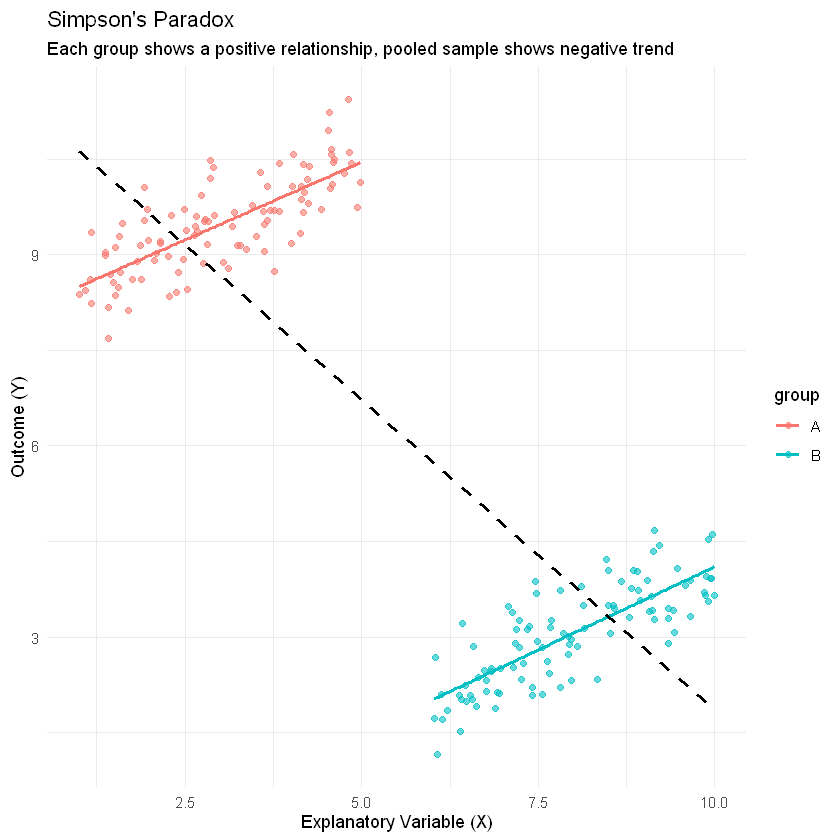

In [34]:
# Load libraries
library(ggplot2)

# Set seed for reproducibility
set.seed(123)

# -------------------------
# Simulate data
# -------------------------
n <- 100

# Group A: positive relationship
x_A <- runif(n, 1, 5)
y_A <- 2 + 0.5 * x_A + rnorm(n, sd = 0.5)

# Group B: positive relationship but different intercept
x_B <- runif(n, 6, 10)
y_B <- 1 + 0.5 * x_B + rnorm(n, sd = 0.5)

# Combine into a data frame
data <- data.frame(
  x = c(x_A, x_B),
  y = c(y_A, y_B),
  group = rep(c("A", "B"), each = n)
)

# Adjust to create Simpson’s paradox (negative pooled trend)
# Shift group means
data$y[data$group == "A"] <- data$y[data$group == "A"] + 6
data$y[data$group == "B"] <- data$y[data$group == "B"] - 2

# -------------------------
# Plot
# -------------------------
p <- ggplot(data, aes(x = x, y = y, color = group)) +
  geom_point(alpha = 0.6) +
  # Regression lines by group
  geom_smooth(method = "lm", se = FALSE) +
  # Overall regression line
  geom_smooth(aes(group = 1), method = "lm", color = "black", se = FALSE, linetype = "dashed") +
  labs(
    title = "Simpson's Paradox",
    subtitle = "Each group shows a positive relationship, pooled sample shows negative trend",
    x = "Explanatory Variable (X)",
    y = "Outcome (Y)"
  ) +
  theme_minimal()

# Show plot in notebook
print(p)

# -------------------------
# Save plot
# -------------------------
ggsave(
  filename = "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/R/Output/simpsons_paradox.png",
  plot = p,
  width = 8,
  height = 6
)


# Part 2 - Can we omit some controls?

Warning message in FUN(X[[i]], ...):
"reiniciar evaluación premisa interrumpida"
Warning message in FUN(X[[i]], ...):
"internal error 1 in R_decompress1 with libdeflate"
ERROR while rich displaying an object: Error in FUN(X[[i]], ...): lazy-load database 'C:/Users/VICTOR/anaconda3/envs/envtest/Lib/R/library/base64enc/R/base64enc.rdb' is corrupt

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% nam

HTML widgets cannot be represented in plain text (need html)


Call:
lm(formula = Y ~ X + Z1 + Z2, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.3346 -0.9001  0.0152  0.8496  3.9011 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.003655   0.039783  -0.092    0.927    
X            0.969122   0.040116  24.158   <2e-16 ***
Z1           1.113346   0.056646  19.655   <2e-16 ***
Z2           1.582900   0.049592  31.919   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 1.258 on 996 degrees of freedom
Multiple R-squared:  0.9245,	Adjusted R-squared:  0.9243 
F-statistic:  4068 on 3 and 996 DF,  p-value: < 2.2e-16



Call:
lm(formula = Y ~ X + Z1 + Z2 + Z3, data = dat)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.0388 -0.6785  0.0330  0.6661  3.4578 

Coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept) -0.03672    0.03160  -1.162    0.245    
X            1.00118    0.03186  31.425   <2e-16 ***
Z1           1.02315    0.04510  22.685   <2e-16 ***
Z2           0.98141    0.04653  21.092   <2e-16 ***
Z3           1.10744    0.04571  24.225   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.998 on 995 degrees of freedom
Multiple R-squared:  0.9525,	Adjusted R-squared:  0.9523 
F-statistic:  4992 on 4 and 995 DF,  p-value: < 2.2e-16


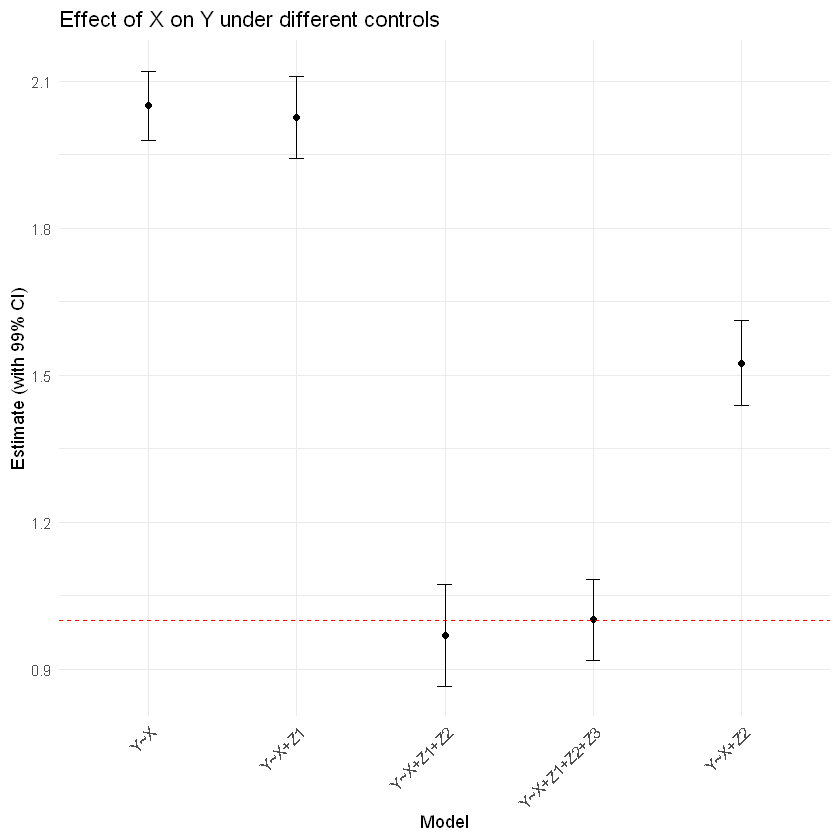

In [40]:
# --------------------------
# Part 2 - Can we omit some controls?
# --------------------------

library(DiagrammeR)
library(ggplot2)

set.seed(123)

# 1) DAG
dag_code <- "
digraph part2 {
  rankdir=LR
  X [label='X']
  Y [label='Y']
  Z1 [label='Z1']
  Z2 [label='Z2']
  Z3 [label='Z3']

  Z1 -> X
  Z1 -> Y
  Z2 -> X
  Z2 -> Y
  Z3 -> Z2
  Z3 -> Y
  X -> Y
}
"
grViz(dag_code)

# 2) Simulate data
n <- 1000
Z1 <- rnorm(n)
Z3 <- rnorm(n)
Z2 <- Z3 + rnorm(n)
X  <- Z1 + Z2 + rnorm(n)
Y  <- X + Z1 + Z2 + Z3 + rnorm(n)
dat <- data.frame(Y, X, Z1, Z2, Z3)

# 3) Regressions
fit1 <- lm(Y ~ X, data = dat)
fit2 <- lm(Y ~ X + Z1, data = dat)
fit3 <- lm(Y ~ X + Z2, data = dat)
fit4 <- lm(Y ~ X + Z1 + Z2, data = dat)
fit5 <- lm(Y ~ X + Z1 + Z2 + Z3, data = dat)

# 4) Collect estimates & 99% CI
fits <- list(fit1, fit2, fit3, fit4, fit5)
labels <- c("Y~X", "Y~X+Z1", "Y~X+Z2", "Y~X+Z1+Z2", "Y~X+Z1+Z2+Z3")

get_ci <- function(fit) {
  est <- coef(summary(fit))["X", "Estimate"]
  se  <- coef(summary(fit))["X", "Std. Error"]
  ci  <- est + c(-1,1) * qnorm(0.995) * se
  c(est, ci)
}

results <- data.frame(
  Model = labels,
  t(sapply(fits, get_ci))
)
colnames(results) <- c("Model", "Estimate", "CI_low", "CI_high")

# 5) Plot results
ggplot(results, aes(x = Model, y = Estimate)) +
  geom_point() +
  geom_errorbar(aes(ymin = CI_low, ymax = CI_high), width = 0.1) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  labs(title = "Effect of X on Y under different controls",
       y = "Estimate (with 99% CI)") +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1))

# 6) Summaries (4) and (5)
summary(fit4)
summary(fit5)


- Which regressions seem to estimate the effect correctly?

The regressions that include both Z1 and Z2 (model 4) and the one that additionally includes Z3 (model 5) provide unbiased estimates of the effect of X on Y. In both cases, the estimated coefficient of X is very close to the true causal effect of 1.

- Can we ignore some Z ∈ {Z1, Z2, Z3} and still get a good estimate?

Yes. Z3 can be ignored if the goal is only to obtain an unbiased estimate of the effect of X on Y. Controlling for Z1 and Z2 is sufficient because they block the backdoor paths that confound the relationship between X and Y. Including Z3 improves precision but is not strictly necessary for unbiasedness.

# Part 3 - Damned if you do, damned if you don't 

Warning message in FUN(X[[i]], ...):
"reiniciar evaluación premisa interrumpida"
Warning message in FUN(X[[i]], ...):
"internal error 1 in R_decompress1 with libdeflate"
ERROR while rich displaying an object: Error in FUN(X[[i]], ...): lazy-load database 'C:/Users/VICTOR/anaconda3/envs/envtest/Lib/R/library/base64enc/R/base64enc.rdb' is corrupt

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% nam

HTML widgets cannot be represented in plain text (need html)

Warning message in FUN(X[[i]], ...):
"reiniciar evaluación premisa interrumpida"
Warning message in FUN(X[[i]], ...):
"internal error 1 in R_decompress1 with libdeflate"
ERROR while rich displaying an object: Error in FUN(X[[i]], ...): lazy-load database 'C:/Users/VICTOR/anaconda3/envs/envtest/Lib/R/library/base64enc/R/base64enc.rdb' is corrupt

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% nam

HTML widgets cannot be represented in plain text (need html)

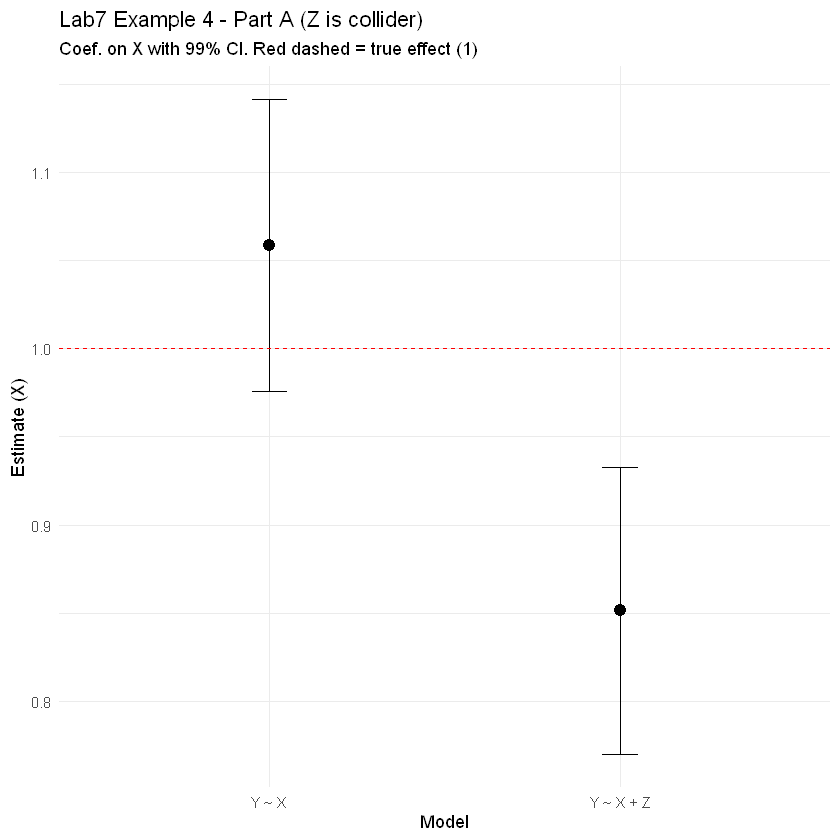

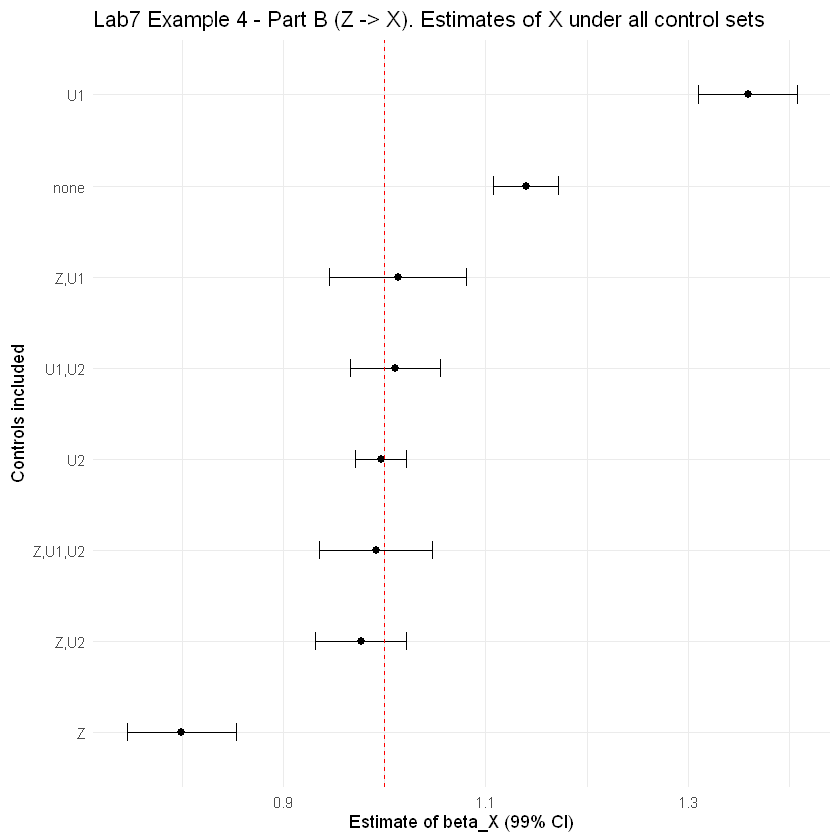

In [42]:
out_dir <- "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/R/Output"
# lab7_example4.R
# Minimal script for "Example 4 (Damned if you do, damned if you don't)"
# -- Simulate, regress, plot, and save table of estimates & SEs.
#
# Requirements: DiagrammeR, DiagrammeRsvg, rsvg, ggplot2

# ---------------------------
# Settings
# ---------------------------
out_dir <- "C:/Users/VICTOR/Documents/GitHub/DAGs_CausalML/R/Output"
dir.create(out_dir, recursive = TRUE, showWarnings = FALSE)

# ---------------------------
# Libraries (quiet)
# ---------------------------
suppressMessages(library(DiagrammeR))
suppressMessages(library(DiagrammeRsvg))
suppressMessages(library(rsvg))
suppressMessages(library(ggplot2))

set.seed(2025)

# ---------------------------
# Part A: Original DAG (Z is collider) + simulation
# DAG:
# U1 -> X
# U1 -> Z
# U2 -> Z
# U2 -> Y
# X  -> Y
# ---------------------------
dagA <- "
digraph DAG_A {
  rankdir=LR;
  U1 [label='U1', shape=ellipse];
  Z  [label='Z',  shape=ellipse];
  U2 [label='U2', shape=ellipse];
  X  [label='X',  shape=box];
  Y  [label='Y',  shape=box];

  U1 -> X;
  U1 -> Z;
  U2 -> Z;
  U2 -> Y;
  X  -> Y;
}
"

# show DAG (silent)
suppressMessages(grViz(dagA))

# Export DAG A (silently) — optional, comment out if not needed
suppressWarnings(
  grViz(dagA) %>%
    DiagrammeRsvg::export_svg() %>%
    charToRaw() %>%
    rsvg::rsvg_png(file.path(out_dir, "lab7_dagA.png"))
)

# Simulation for DAG A
n <- 1000
U1 <- rnorm(n)
U2 <- rnorm(n)
Z  <- 1*U1 + 1*U2 + rnorm(n)   # Z is collider U1->Z<-U2
X  <- 1*U1 + rnorm(n)          # X <- U1
Y  <- 1*X + 1*U2 + rnorm(n)    # Y <- X and <- U2

datA <- data.frame(Y, X, Z, U1, U2)

# Regressions required: Y ~ X  and  Y ~ X + Z
fitA1 <- lm(Y ~ X, data = datA)
fitA2 <- lm(Y ~ X + Z, data = datA)

# Extract X coefficient + 99% CI for both
coef_A <- function(fit) {
  est <- coef(summary(fit))["X", "Estimate"]
  se  <- coef(summary(fit))["X", "Std. Error"]
  ci  <- est + c(-1,1) * qnorm(0.995) * se
  c(estimate = est, se = se, ci_low = ci[1], ci_high = ci[2])
}
a1 <- coef_A(fitA1)
a2 <- coef_A(fitA2)

resA <- data.frame(
  Model = c("Y ~ X", "Y ~ X + Z"),
  Estimate = c(a1["estimate"], a2["estimate"]),
  SE = c(a1["se"], a2["se"]),
  CI_low = c(a1["ci_low"], a2["ci_low"]),
  CI_high = c(a1["ci_high"], a2["ci_high"]),
  stringsAsFactors = FALSE
)

# Plot coefficients (Part A)
pA <- ggplot(resA, aes(x = Model, y = Estimate)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = CI_low, ymax = CI_high), width = 0.1) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  labs(title = "Lab7 Example 4 - Part A (Z is collider)",
       subtitle = "Coef. on X with 99% CI. Red dashed = true effect (1)",
       y = "Estimate (X)") +
  theme_minimal()

print(pA)

# ---------------------------
# Part B: Modified DAG (Z -> X) and U1, U2 observed
# Now DAG edges:
# U1 -> X
# U1 -> Z
# U2 -> Z
# U2 -> Y
# X  -> Y
# Z  -> X   (added)
# We assume U1 and U2 are observable and controllable
# ---------------------------
dagB <- "
digraph DAG_B {
  rankdir=LR;
  U1 [label='U1', shape=ellipse];
  Z  [label='Z',  shape=ellipse];
  U2 [label='U2', shape=ellipse];
  X  [label='X',  shape=box];
  Y  [label='Y',  shape=box];

  U1 -> X;
  U1 -> Z;
  U2 -> Z;
  U2 -> Y;
  X  -> Y;
  Z  -> X;
}
"

suppressMessages(grViz(dagB))

# Export DAG B (optional)
suppressWarnings(
  grViz(dagB) %>%
    DiagrammeRsvg::export_svg() %>%
    charToRaw() %>%
    rsvg::rsvg_png(file.path(out_dir, "lab7_dagB.png"))
)

# Simulation for DAG B
set.seed(2025)
n <- 2000
U1 <- rnorm(n)
U2 <- rnorm(n)
Z  <- 1*U1 + 1*U2 + rnorm(n)
X  <- 1*U1 + 0.8*Z + rnorm(n)   # now Z -> X as well
Y  <- 1*X + 1*U2 + rnorm(n)     # Y <- X and <- U2

datB <- data.frame(Y, X, Z, U1, U2)

# All combinations of controls among Z, U1, U2 (2^3 = 8)
controls_list <- list(
  c(), c("Z"), c("U1"), c("U2"),
  c("Z","U1"), c("Z","U2"), c("U1","U2"), c("Z","U1","U2")
)

names_list <- sapply(controls_list, function(x) if (length(x)==0) "none" else paste(x, collapse=","))

estimates <- data.frame(controls = names_list, beta = NA_real_, se = NA_real_, stringsAsFactors = FALSE)

for (i in seq_along(controls_list)) {
  ctrls <- controls_list[[i]]
  rhs <- paste(c("X", ctrls), collapse = " + ")
  f <- as.formula(paste("Y ~", rhs))
  fit <- lm(f, data = datB)
  est <- coef(summary(fit))["X", "Estimate"]
  se  <- coef(summary(fit))["X", "Std. Error"]
  estimates$beta[i] <- est
  estimates$se[i]   <- se
}

# 99% CI columns (if you want to plot)
z99 <- qnorm(0.995)
estimates$ci_low <- estimates$beta - z99 * estimates$se
estimates$ci_high <- estimates$beta + z99 * estimates$se

# Plot all 8 estimates with 99% CI and true effect line (1)
pB <- ggplot(estimates, aes(x = reorder(controls, beta), y = beta)) +
  geom_point(size = 2) +
  geom_errorbar(aes(ymin = ci_low, ymax = ci_high), width = 0.2) +
  geom_hline(yintercept = 1, linetype = "dashed", color = "red") +
  coord_flip() +
  labs(title = "Lab7 Example 4 - Part B (Z -> X). Estimates of X under all control sets",
       x = "Controls included",
       y = "Estimate of beta_X (99% CI)") +
  theme_minimal()

print(pB)

# ---------------------------
# Save table (beta and SE) to out_dir as txt and tex
# ---------------------------
# Minimal .txt: tab-delimited with header "beta" and "SE" (row names = controls)
tab_out <- estimates[, c("controls", "beta", "se")]
colnames(tab_out) <- c("Controls", "beta", "SE")
write.table(tab_out, file = file.path(out_dir, "lab7_example4_beta_se.txt"),
            sep = "\t", row.names = FALSE, quote = FALSE)

# Minimal .tex table
tex_lines <- c("\\begin{tabular}{lcc}",
               "\\hline",
               "Controls & $\\beta$ & SE \\\\",
               "\\hline")
for (i in seq_len(nrow(tab_out))) {
  tex_lines <- c(tex_lines,
                 sprintf("%s & %.4f & %.4f \\\\", tab_out$Controls[i], tab_out$beta[i], tab_out$SE[i]))
}
tex_lines <- c(tex_lines, "\\hline", "\\end{tabular}")
writeLines(tex_lines, con = file.path(out_dir, "lab7_example4_beta_se.tex"))




- Part A (Z is collider): Regressing Y ~ X gives an unbiased estimate of X; conditioning on Z (Y ~ X + Z) introduces bias because Z is a collider (U1 -> Z <- U2) and conditioning on it opens a spurious path.

- Part B (Z -> X; U1 and U2 observable): Running the 2^3 regressions shows which control sets recover the true effect (1). In this DGP controlling for U2 (or controlling for U1 and U2 together) yields estimates close to 1. Controlling Z alone produces biased estimates. The minimal sufficient set to obtain an unbiased estimate is {U2} (or {U1,U2}); including Z is not necessary for unbiasedness but may affect precision depending on the combination.